F1 Circuit Complexity Index
--------
Formula 1 is the peak of motorsport where only the best drivers from around the world are allowed behind the wheel and onto the track. Each track is unique and has its own set of technical and physical challenges the drivers must adapt to. This analysis looks to develop a composite indicator designed to quantify the difficulty of all circuits.

### Finding the data

To create this index I am going to need to combine a few datasets. I will need data about the circuits that includes their length, number of corners, height elevation, top speed etc. To better show how difficult a track is I will also seek out a dataset containing all safety cars deployed and their reason for each track. 

I am interested to see how the safety car dataset will influence the result as you could argue that a track that has more safety cars is more difficult. Finally I will attempt to find a dataset containing time penalties given to drivers, specifically track limit penalties. This occurs when all four tyres cross the white line markings of the track edge, possibly indicating a higher difficulty.


- Data Sources
1. <a href="https://mintlify.wiki/TracingInsights/RaceData/introduction">RaceData</a>
2. <a href="https://www.kaggle.com/datasets/kishan305/formula-1-circuits-1950-present">Kaggle - Formula 1 Circuits (1950 - Present)</a>


**Race Data** is a comprehensive Formula 1 race data from 1950 to present. They provide 18 data tables that will provide me with safety car, red flags and fatal accident data.

**Kaggle** Although RaceData does provide a dataset on all circuits I have opted to use this kaggle dataset as there is more technical information about each track in it.


TODO: Talk about low amount of data rows but lots of data points, I have captured nearly all of the circuits and it is about data quality not quantity

In [316]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.decomposition import PCA

circuit_metrics = pd.read_csv("data/all_f1_circuits.csv")
circuit_metrics.head()

,Circuit,City,Country,Track Length (km),Turns,Direction,Circuit Type,First Grand Prix,Last Grand Prix,Races,Best Lap Timing,Best Lap Driver,Best Lap Year,Best Lap Time
0,Brands Hatch,Fawkham,United Kingdom,4.207,9,Clockwise,Race,1964 British Grand Prix,1986 British Grand Prix,14,1:09.593,Nigel Mansell,1986,69.593
1,AVUS,Berlin,Germany,8.300,4,Anti clockwise,Road,1959 German Grand Prix,1959 German Grand Prix,1,2:04.500,Tony Brooks,1959,124.500
2,Autodromo Internazionale Enzo e Dino Ferrari,Imola,Italy,4.909,19,Anti clockwise,Race,1980 Italian Grand Prix,2025 Emilia Romagna Grand Prix,32,1:15.484,Lewis Hamilton,2020,75.484
3,Autódromo Juan y Oscar Gálvez,Buenos Aires,Argentina,4.259,19,Clockwise,Race,1953 Argentine Grand Prix,1998 Argentine Grand Prix,20,1:11.220,Emerson Fittipaldi,1973,71.220
4,Autodromo Internazionale del Mugello,Scarperia e San Piero,Italy,5.245,15,Clockwise,Race,2020 Tuscan Grand Prix,2020 Tuscan Grand Prix,1,1:18.833,Lewis Hamilton,2020,78.833


In [317]:
safety_cars = pd.read_csv("data/safety_cars.csv")
safety_cars.head()

,Race,Cause,Deployed,Retreated,FullLaps
0,1973 Canadian Grand Prix,Accident,33,39.0,5
1,1993 Brazilian Grand Prix,Accident/Rain,29,38.0,8
2,1993 British Grand Prix,Stranded car,38,40.0,1
3,1994 San Marino Grand Prix,Accident,1,6.0,4
4,1995 Belgian Grand Prix,Rain,28,33.0,4


In [318]:
red_flags = pd.read_csv("data/red_flags.csv")
red_flags.head()

,Race,Lap,Resumed,Incident,Excluded
0,1950 Indianapolis 500,138,N,Rain.,NaN
1,1971 Canadian Grand Prix,64,N,Mist.,NaN
2,1973 British Grand Prix,2,Y,"Crash involving Jody Scheckter, Jean-Pierre Be...","Jody Scheckter, Jean-Pierre Beltoise, George F..."
3,1974 Brazilian Grand Prix,32,N,Rain.,NaN
4,1975 Spanish Grand Prix,29,N,Crash of Rolf Stommelen which killed five spec...,NaN


In [319]:
# fatal_accidents_drivers = pd.read_csv("data/fatal_accidents_drivers.csv")
# fatal_accidents_drivers.head()

In [320]:
## Added during selecting variables
circuit_info = pd.read_csv("data/circuits.csv")
circuit_info.head()

,circuitId,circuitRef,name,location,country,lat,lng,alt,url
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.96800,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.73800,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
2,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.51060,7,http://en.wikipedia.org/wiki/Bahrain_Internati...
3,4,catalunya,Circuit de Barcelona-Catalunya,Montmeló,Spain,41.57000,2.26111,109,http://en.wikipedia.org/wiki/Circuit_de_Barcel...
4,5,istanbul,Istanbul Park,Istanbul,Turkey,40.95170,29.40500,130,http://en.wikipedia.org/wiki/Istanbul_Park


### Selecting Variables

To select my variables I am using excel to view the raw data. What is referenced will be from those observations but I will show what I am talking about through visualization here. As the data is coming from 2 different sources there are likely some discrepancies hidden in them. For example the above head of fatal_accidents_driver and red_flags have NaN values, some tracks are describe using a slightly different name. 


Something important I have to consider to ensure this index is accurate is what is the cut off year before I start excluding race data from my data set. I think this because if you look back at what the level of safety standards were back in 1950 to 1980 they were basically non-existent. Only until the mid 90s did the FIA enforce strict rules on the teams and cars. With this in mind and before fully getting into this data i think it would be best to use race data from the year 2000 until present.

In [321]:
master_data = pd.DataFrame()
circuit_master = pd.DataFrame()
safety_car_master = pd.DataFrame()
red_flag_master = pd.DataFrame()


#### All Circuits

Although the race name is not important for the index result, it will be a key part of linking the data together. Something I immediately noticed is that all_f1_circuits.csv  uses the proper circuit name and the others use a format of - $Year + Country + Grand Prix$. In all_circuits_f1 I am given the city and the country but using this as a link will fail on races like British and Italian as these are now the country names. To get passed this im going to use the circuits data provided by RaceData which contains the name of the circuit. 

By merging these two together I can also include the circuitId provided by circuits.csv to then use as a link to all the other datasets from RaceData making it much easier to add data to my problem.

In [322]:
# sorted by name to show how they line up
sorted_metrics = circuit_metrics.sort_values(by='Circuit')
sorted_info = circuit_info.sort_values(by='name')

print("(Kaggle) all_f1_circuits.csv description of track")
print(list(sorted_metrics.Circuit.values))
print(f"Length - {len(sorted_metrics)}")
print("\n(RaceData) circuits.csv description of track")
print(list(sorted_info.name.values))
print(f"Length - {len(sorted_info)}")

(Kaggle) all_f1_circuits.csv description of track
['AVUS', 'Adelaide Street Circuit', 'Ain-Diab Circuit', 'Aintree Motor Racing Circuit', 'Algarve International Circuit', 'Anderstorp Raceway', 'Autodromo Internazionale Enzo e Dino Ferrari', 'Autodromo Internazionale del Mugello', 'Autodromo Nazionale Monza', 'Autódromo Hermanos Rodríguez', 'Autódromo Internacional Nelson Piquet', 'Autódromo José Carlos Pace', 'Autódromo Juan y Oscar Gálvez', 'Autódromo do Estoril', 'Bahrain International Circuit', 'Baku City Circuit', 'Brands Hatch', 'Buddh International Circuit', 'Bugatti Circuit', 'Caesars Palace', 'Canadian Tire Motorsport Park', 'Charade Circuit', 'Circuit Bremgarten', 'Circuit Gilles Villeneuve', 'Circuit Mont-Tremblant', 'Circuit Park Zandvoort', 'Circuit Paul Ricard', 'Circuit Zolder', 'Circuit de Barcelona-Catalunya', 'Circuit de Monaco', 'Circuit de Nevers Magny-Cours', 'Circuit de Spa-Francorchamps', 'Circuit of the Americas', 'Circuito da Boavista', 'Circuito de Jerez', 'Cir

There is 1 race missing from the all_f1_circuits and also some of the circuits still come under a different name. I will find the ones that match and review the misaligned ones using python sets. 

In [323]:
# first I want to check how many of the circuit names match between the datasets
matching_circuits = []
match_count = 0
bad_count = 0
print(len(circuit_metrics))
print(len(circuit_info))

# create sets of the unique names in both columns
circuit_names1 = set(circuit_metrics['Circuit'])
circuit_names2 = set(circuit_info['name']) # Replace with your actual column name

# using intersection to get a list of matching items between the sets - https://www.w3schools.com/python/ref_set_intersection.asp
matches = circuit_names1.intersection(circuit_names2)
metrics_mismatches = circuit_names1.difference(circuit_names2)
info_mismatches = circuit_names2.difference(circuit_names1)

print(metrics_mismatches)
print(info_mismatches)
print(f"Matches: {len(matches)}")
print(f"Circuit Metrics: {len(metrics_mismatches)}")
print(f"Circuit Info: {len(info_mismatches)}")

77
78
{'Lusail International Circuit', 'Korea International Circuit', 'Circuito del Jarama', 'Phoenix Street Circuit', 'Circuit Zolder', 'Aintree Motor Racing Circuit', 'Autodromo Internazionale Enzo e Dino Ferrari', 'Bugatti Circuit', 'Watkins Glen International', 'Circuito de Montjuïc', 'Algarve International Circuit', 'Caesars Palace', 'Anderstorp Raceway', 'Kyalami Racing Circuit', 'Ain-Diab Circuit', 'Melbourne Grand Prix Circuit', 'Circuito de Monsanto', 'Canadian Tire Motorsport Park', 'Autodromo Nazionale Monza', 'Pedralbes Circuit'}
{'Albert Park Grand Prix Circuit', 'Mosport International Raceway', 'Madring', 'Montjuïc', 'Kyalami', 'Circuit de Pedralbes', 'Jarama', 'Monsanto Park Circuit', 'Autodromo Nazionale di Monza', 'Phoenix street circuit', 'Autódromo Internacional do Algarve', 'Korean International Circuit', 'Aintree', 'Ain Diab', 'Zolder', 'Le Mans', 'Losail International Circuit', 'Autodromo Enzo e Dino Ferrari', 'Scandinavian Raceway', 'Las Vegas Strip Street Circui

In [324]:
print(sorted(metrics_mismatches))
print(sorted(info_mismatches))

['Ain-Diab Circuit', 'Aintree Motor Racing Circuit', 'Algarve International Circuit', 'Anderstorp Raceway', 'Autodromo Internazionale Enzo e Dino Ferrari', 'Autodromo Nazionale Monza', 'Bugatti Circuit', 'Caesars Palace', 'Canadian Tire Motorsport Park', 'Circuit Zolder', 'Circuito de Monsanto', 'Circuito de Montjuïc', 'Circuito del Jarama', 'Korea International Circuit', 'Kyalami Racing Circuit', 'Lusail International Circuit', 'Melbourne Grand Prix Circuit', 'Pedralbes Circuit', 'Phoenix Street Circuit', 'Watkins Glen International']
['Ain Diab', 'Aintree', 'Albert Park Grand Prix Circuit', 'Autodromo Enzo e Dino Ferrari', 'Autodromo Nazionale di Monza', 'Autódromo Internacional do Algarve', 'Circuit de Pedralbes', 'Jarama', 'Korean International Circuit', 'Kyalami', 'Las Vegas Strip Street Circuit', 'Le Mans', 'Losail International Circuit', 'Madring', 'Monsanto Park Circuit', 'Montjuïc', 'Mosport International Raceway', 'Phoenix street circuit', 'Scandinavian Raceway', 'Watkins Gle

Looking at the circuits the easiest thing I can do here is create a mapping dict that I can refer back to in a loop to get the correct circuit. Looking through the lists I have found that Madring is the missing circuit. I have opted to exclude it from the data.

In [325]:
# all_f1_circuit.csv as key | circuits.csv as value
# to get this mapping data I copied the above lists the I generated and asked an LLM to find the matching sets and produce a map.
circuit_mapping = {
    'Ain-Diab Circuit': 'Ain Diab',
    'Aintree Motor Racing Circuit': 'Aintree',
    'Algarve International Circuit': 'Autódromo Internacional do Algarve',
    'Anderstorp Raceway': 'Scandinavian Raceway',
    'Autodromo Internazionale Enzo e Dino Ferrari': 'Autodromo Enzo e Dino Ferrari',
    'Autodromo Nazionale Monza': 'Autodromo Nazionale di Monza',
    'Bugatti Circuit': 'Le Mans',
    'Caesars Palace': 'Las Vegas Strip Street Circuit', 
    'Canadian Tire Motorsport Park': 'Mosport International Raceway',
    'Circuit Zolder': 'Zolder',
    'Circuito de Monsanto': 'Monsanto Park Circuit',
    'Circuito de Montjuïc': 'Montjuïc',
    'Circuito del Jarama': 'Jarama',
    'Korea International Circuit': 'Korean International Circuit',
    'Kyalami Racing Circuit': 'Kyalami',
    'Lusail International Circuit': 'Losail International Circuit',
    'Melbourne Grand Prix Circuit': 'Albert Park Grand Prix Circuit',
    'Pedralbes Circuit': 'Circuit de Pedralbes',
    'Phoenix Street Circuit': 'Phoenix street circuit',
    'Watkins Glen International': 'Watkins Glen'
}

In [326]:
uncombined_metrics = circuit_metrics[['Circuit', 'Track Length (km)', 'Turns', 'Direction', 'Circuit Type']]
uncombined_info = circuit_info[['circuitId', 'name', 'country', 'alt']]
combined_data = []

for index_m, row_m in uncombined_metrics.iterrows():
    circuit_name = row_m['Circuit']
    
    target_search_name = circuit_mapping.get(circuit_name, circuit_name)
    
    found = False
    for index_i, row_i in uncombined_info.iterrows():
        if row_i['name'] == target_search_name:
            # convert circuit type to binary variable, 0 for Race, 1 for Street, 2 for Road
            type = 0
            if row_m['Circuit Type'] == "Race":
                type = 0
            elif row_m['Circuit Type'] == "Street":
                type = 1
            else:
                type = 2
            combined_row = {
                'Circuit': circuit_name,
                'Track_Length': row_m['Track Length (km)'],
                'Turns': row_m['Turns'],
                'Direction': 1 if row_m['Direction'] == 'Clockwise' else 0, # turn direction into 1 or 0, 1 for Clockwise, 0 for Counterclockwise
                'Altitude': row_i['alt'],
                'Circuit_Type': type,
                'circuitId': row_i['circuitId'],
                # 'country': row_i['country']
            }
            combined_data.append(combined_row)
            found = True
            # print(f"match: {circuit_name} - {target_search_name}")
            break

circuit_master = pd.DataFrame(combined_data)
print(circuit_master.head())
# print(type(circuit_master))
# print(len(circuit_master))

                                        Circuit  Track_Length  Turns  \
0                                  Brands Hatch         4.207      9   
1                                          AVUS         8.300      4   
2  Autodromo Internazionale Enzo e Dino Ferrari         4.909     19   
3                 Autódromo Juan y Oscar Gálvez         4.259     19   
4          Autodromo Internazionale del Mugello         5.245     15   

   Direction  Altitude  Circuit_Type  circuitId  
0          1       145             0         38  
1          0        53             2         61  
2          0        37             0         21  
3          1         8             0         25  
4          1       255             0         76  


#### Now that I have combined these two datasets the rest can be combined using circuitId taken from the RaceData dataset

#### Safety Cars

In [327]:
safety_cars.head()

,Race,Cause,Deployed,Retreated,FullLaps
0,1973 Canadian Grand Prix,Accident,33,39.0,5
1,1993 Brazilian Grand Prix,Accident/Rain,29,38.0,8
2,1993 British Grand Prix,Stranded car,38,40.0,1
3,1994 San Marino Grand Prix,Accident,1,6.0,4
4,1995 Belgian Grand Prix,Rain,28,33.0,4


To my surprise, even though the safety_cars.csv comes from the same source that uses circuitId, the only useful variable to match is the race name. This race name does not match what I have just done above...

This dataset contains 3 data points

**Cause**: Why a safety car was deployed on track<br>
**Deployed**: The lap which the safety car left the pit lane<br>
**FullLaps**: Number of full laps around the circuit before safety car returned<br>

All I care about is the amount of times a safety car was called on track. So I need to filter out the tra

In [328]:
# TODO: pull out year and add it as a column to safety cars. Will allow me to group by year >= 2000
years = []
for index, row in safety_cars.iterrows():
  year = row.Race.split()[0]
  years.append(year)

# add years to safety cars, used for filtering later
safety_cars['Year'] = years
print(f"Length of safety cars df - {len(safety_cars)}")
print(f"Length of extracted years - {len(years)}")

# print(safety_cars.head())

filtered_safety_cars = safety_cars[safety_cars['Year'] >= '2000']
filtered_safety_cars['GP_Name'] = safety_cars['Race'].apply(lambda x: " ".join(x.split()[1:]))

print(f"Length of filtered safety cars df (Year >= 2000) - {len(filtered_safety_cars)}")

# Removing columns that wont be used 
filtered_safety_cars.drop(columns=['Cause', 'Deployed', 'FullLaps', 'Retreated', 'Race'], inplace=True)

print(filtered_safety_cars.head())



Length of safety cars df - 366
Length of extracted years - 366
Length of filtered safety cars df (Year >= 2000) - 343
    Year                GP_Name
23  2000  Australian Grand Prix
24  2000    Austrian Grand Prix
25  2000      German Grand Prix
26  2000      German Grand Prix
27  2000     Belgian Grand Prix


Now that I have pulled the year out of each row and added it as a new column, I will be able to filter out races from certain years. Next I want to pull out the race name and count the occurrence and that will be the important information from safety cars.

In [329]:
safety_cars_count = filtered_safety_cars.groupby('GP_Name').size().reset_index(name='Safety_Car_Count')
print(safety_cars_count)

                      GP_Name  Safety_Car_Count
0        Abu Dhabi Grand Prix                 6
1       Australian Grand Prix                29
2         Austrian Grand Prix                13
3       Azerbaijan Grand Prix                 9
4          Bahrain Grand Prix                 9
5          Belgian Grand Prix                18
6        Brazilian Grand Prix                20
7          British Grand Prix                21
8         Canadian Grand Prix                24
9          Chinese Grand Prix                13
10           Dutch Grand Prix                 6
11           Eifel Grand Prix                 1
12  Emilia Romagna Grand Prix                 4
13        European Grand Prix                 4
14          French Grand Prix                 2
15          German Grand Prix                11
16       Hungarian Grand Prix                 7
17         Italian Grand Prix                10
18        Japanese Grand Prix                15
19          Korean Grand Prix           

Now I have a list of all circuits that have had a safety car deployed between the year 2000 and present. 

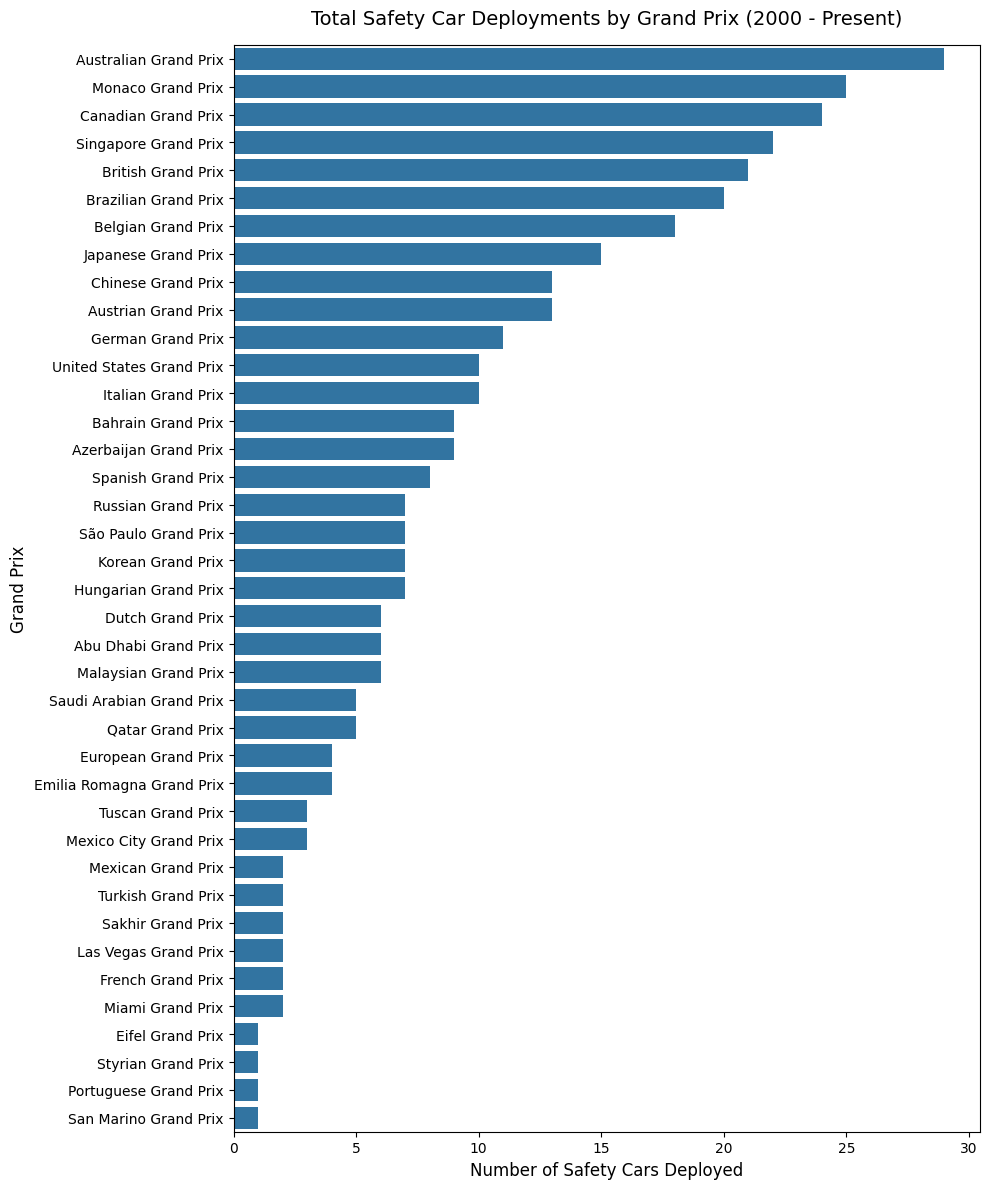

In [330]:
safety_cars_count = safety_cars_count.sort_values(by='Safety_Car_Count', ascending=False)

# 5. Create the plot
plt.figure(figsize=(10, 12))  # Taller height ensures every race name has room to breathe
sns.barplot(
    data=safety_cars_count, 
    x='Safety_Car_Count', 
    y='GP_Name', 
)

# 6. Customize labels and title so it looks professional
plt.title('Total Safety Car Deployments by Grand Prix (2000 - Present)', fontsize=14, pad=15)
plt.xlabel('Number of Safety Cars Deployed', fontsize=12)
plt.ylabel('Grand Prix', fontsize=12)

# Adjust layout automatically so no labels are truncated
plt.tight_layout()
plt.show()

Looking at this bar chart and being an F1 fan myself, I can see that races that have been in the race schedule for almost every season since 1950 have a quite have safety car deployment rate. Some of these races like the Miami Grand Prix only started happening within the last few years.


To balancing this out across all races I will get an average safety car count per circuit based on how many times it was raced since 2000
$$\text{Safety Car Rate} = \frac{\text{Total Safety Cars}}{\text{Total Races Hosted}}$$

I will need to use the races.csv to count how many times a track has been raced since 2000

In [331]:
races = pd.read_csv("data/races.csv")
races.head()
print(f"Count - {len(races)}")

Count - 1171


In [332]:
filtered_races = races[races['year'] >= 2000].copy()
print(f"Count - {len(filtered_races)}")

Count - 525


In [333]:

# Count the circuitIds and created a new column called Races_Hosted to hold this number
races_hosted_counts = filtered_races.groupby('circuitId').size().reset_index(name='Races_Hosted')
print(races_hosted_counts.head())
# Create new column that matches GP_Name in safety cars, safety cars will have cirucitId have this merge from races
races['Race_Match'] = races['year'].astype(str) + " " + races['name']
races.head()

   circuitId  Races_Hosted
0          1            25
1          2            18
2          3            22
3          4            27
4          5             9


,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time,Race_Match
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N,2009 Australian Grand Prix
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N,2009 Malaysian Grand Prix
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N,2009 Chinese Grand Prix
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N,2009 Bahrain Grand Prix
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N,2009 Spanish Grand Prix


In [334]:
filtered_safety_cars['Year'] = filtered_safety_cars['Year'].astype(int)

# Merge on both columns to get circuitId in the process
sc_with_id = pd.merge(
    filtered_safety_cars,
    races[['year', 'name', 'circuitId']],
    left_on=['Year', 'GP_Name'],
    right_on=['year', 'name'],
    how='left'
)

# Group by the circuitId to count safety cars per track
sc_counts = sc_with_id.groupby('circuitId').size().reset_index(name='Safety_Car_Count')
safety_car_count_master = pd.merge(races_hosted_counts, sc_counts, on='circuitId', how='left')
#Fill tracks that had 0 safety cars with 0 instead of NaN
safety_car_count_master['Safety_Car_Count'] = safety_car_count_master['Safety_Car_Count'].fillna(0)

# Calculate unbiased Average Safety Car Rate per Race
safety_car_count_master['Safety_Car_Rate'] = safety_car_count_master['Safety_Car_Count'] / safety_car_count_master['Races_Hosted']

safety_car_master = safety_car_count_master

print(safety_car_master)

    circuitId  Races_Hosted  Safety_Car_Count  Safety_Car_Rate
0           1            25              29.0         1.160000
1           2            18               6.0         0.333333
2           3            22              11.0         0.500000
3           4            27               8.0         0.296296
4           5             9               2.0         0.222222
5           6            26              25.0         0.961538
6           7            24              24.0         1.000000
7           8             9               0.0         0.000000
8           9            28              21.0         0.750000
9          10            14              10.0         0.714286
10         11            27               7.0         0.259259
11         12             5               2.0         0.400000
12         13            25              18.0         0.720000
13         14            27              10.0         0.370370
14         15            17              22.0         1

#### Red Flags

Red flags can follow the same process as I took for safety cars -
- Extract the year and track from the red flags data.
- Sort by year, merge with races to get an accurate count.
- Create an unbiased red flag rate based on how many times a track was raced.

In [335]:
red_flags['Year'] = red_flags['Race'].str.split().str[0].astype(int)

filtered_red_flags = red_flags[red_flags['Year'] >= 2000].copy()
filtered_red_flags['GP_Name'] = filtered_red_flags['Race'].apply(lambda x: " ".join(x.split()[1:]))

filtered_red_flags.drop(columns=['Lap', 'Resumed', 'Incident', 'Excluded', 'Race'], inplace=True, errors='ignore')
print(filtered_red_flags.head())

    Year               GP_Name
56  2000     Monaco Grand Prix
57  2001     German Grand Prix
58  2001    Belgian Grand Prix
59  2003  Brazilian Grand Prix
60  2007   European Grand Prix


In [336]:
rf_with_id = pd.merge(
    filtered_red_flags,
    races[['year', 'name', 'circuitId']],
    left_on=['Year', 'GP_Name'],
    right_on=['year', 'name'],
    how='left'
)

rf_counts = rf_with_id.groupby('circuitId').size().reset_index(name='Red_Flag_Count')

red_flag_master = pd.merge(races_hosted_counts, rf_counts, on='circuitId', how='left')

red_flag_master['Red_Flag_Count'] = red_flag_master['Red_Flag_Count'].fillna(0)
red_flag_master['Red_Flag_Rate'] = red_flag_master['Red_Flag_Count'] / red_flag_master['Races_Hosted']


print(red_flag_master.sort_values(by='Red_Flag_Rate', ascending=False).head(10))

    circuitId  Races_Hosted  Red_Flag_Count  Red_Flag_Rate
33         76             1             2.0       2.000000
34         77             5             2.0       0.400000
25         35             4             1.0       0.250000
31         73            10             2.0       0.200000
17         18            26             5.0       0.192308
5           6            26             5.0       0.192308
21         22            23             4.0       0.173913
26         39             6             1.0       0.166667
0           1            25             4.0       0.160000
12         13            25             3.0       0.120000


### Combining Datasets

In [337]:
# Check for missing values in your master_data
circuit_master

,Circuit,Track_Length,Turns,Direction,Altitude,Circuit_Type,circuitId
0,Brands Hatch,4.207,9,1,145,0,38
1,AVUS,8.300,4,0,53,2,61
2,Autodromo Internazionale Enzo e Dino Ferrari,4.909,19,0,37,0,21
3,Autódromo Juan y Oscar Gálvez,4.259,19,1,8,0,25
4,Autodromo Internazionale del Mugello,5.245,15,1,255,0,76
...,...,...,...,...,...,...,...
72,Watkins Glen International,5.435,11,1,485,0,46
73,Silverstone Circuit,5.891,18,1,153,0,9
74,Zeltweg,3.186,4,1,676,2,57
75,Yas Marina Circuit,5.281,16,0,3,0,24


In [338]:
safety_car_master

,circuitId,Races_Hosted,Safety_Car_Count,Safety_Car_Rate
0,1,25,29.0,1.160000
1,2,18,6.0,0.333333
2,3,22,11.0,0.500000
3,4,27,8.0,0.296296
4,5,9,2.0,0.222222
5,6,26,25.0,0.961538
6,7,24,24.0,1.000000
7,8,9,0.0,0.000000
8,9,28,21.0,0.750000
9,10,14,10.0,0.714286


In [339]:
red_flag_master

,circuitId,Races_Hosted,Red_Flag_Count,Red_Flag_Rate
0,1,25,4.0,0.160000
1,2,18,2.0,0.111111
2,3,22,1.0,0.045455
3,4,27,0.0,0.000000
4,5,9,0.0,0.000000
5,6,26,5.0,0.192308
6,7,24,1.0,0.041667
7,8,9,0.0,0.000000
8,9,28,3.0,0.107143
9,10,14,1.0,0.071429


Something I noticed when reviewing the data is that in safety_car_master and red_flag_master there is 39 rows of data. In circuit_master there is 77. This is happening because I am only capturing safety cars and red flags that happened between 2000 and the present whereas all circuits from 1950 to present are included. To solve this I will drop the rows that have no safety car or red flag data to ensure integrity.

In [340]:
# merge datasets together on circuitId
master_data = pd.merge(circuit_master, safety_car_master[['circuitId', 'Safety_Car_Rate']], on='circuitId', how='left')
master_data = pd.merge(master_data, red_flag_master[['circuitId', 'Red_Flag_Rate']], on='circuitId', how='left')

# fill empty NaN with 0s
master_data['Safety_Car_Rate'] = master_data['Safety_Car_Rate'].fillna(0)
master_data['Red_Flag_Rate'] = master_data['Red_Flag_Rate'].fillna(0)

# only using tracks that have had at least 1 race since 2000
master_data = master_data[master_data['circuitId'].isin(races_hosted_counts['circuitId'])].copy()


print(f"Total rows preserved: {len(master_data)}")
print(master_data.head())

Total rows preserved: 38
                                        Circuit  Track_Length  Turns  \
2  Autodromo Internazionale Enzo e Dino Ferrari         4.909     19   
4          Autodromo Internazionale del Mugello         5.245     15   
6                             Baku City Circuit         6.003     20   
7                 Bahrain International Circuit         5.412     15   
8                                Caesars Palace         3.650     14   

   Direction  Altitude  Circuit_Type  circuitId  Safety_Car_Rate  \
2          0        37             0         21         0.416667   
4          1       255             0         76         3.000000   
6          0        -7             1         73         0.900000   
7          1         7             0          3         0.500000   
8          0       642             1         80         0.500000   

   Red_Flag_Rate  
2       0.083333  
4       2.000000  
6       0.200000  
7       0.045455  
8       0.000000  


### Thought behind using these variables


1. **Circuit** - Keeping so that it is easier to identify what circuit is being described, rather then looking at circuitId.
2. **Track_Length (km)** - The length of the track sounds like an important metric, maybe a longer track means drivers are under more stress per lap and fatigue could cause a lapse of judgement on track.
3. **Turns** - An important metric about a circuit, distinct to each circuit.
4. **Direction** - 0 = Clockwise | 1 = Counterclockwise | Not sure how this will effect the result, curious to see the outcome.
5. **Altitude** - Tracks at a higher altitude have less air resulting in the car experiencing lower down force. On tracks with more corners there would be a higher chance for a mistake
6. **Circuit_Type** - Street circuits are tight with concrete barriers either side. They are less forgiving to the driver, other types are track with gravel traps that are more forgiving.
7. **circuitId** - Can be used as a relationship link between all datasets
8. **Safety_Car_Rate** - This is where the danger factor comes in. If a track has a higher amount of safety cars deployed then it might be more difficult for the drivers racing against each other
9. **Red_Flag_Rate** - Same thought as safety car, if a red flag is waived then there is a serious issue on track and everyone needs to return to the pits until its cleared. More red flags might mean a harder race.


- For **safety car** and **red flag rate** there was a big difference in some of the numbers, for example Melbourne has 25 red flags and Las Vegas has none. This is because Melbourne has been raced for basically every season and Las Vegas has only been added in the last couple of years. To mitigate this I count how many times a track has experienced a safety car and red flag, then count how many times the circuit has been raced from 2000 to present. This number then divides the total amount of safety cars or red flags for that circuit giving a better average to work with.


$$\text{Safety Car Rate} = \frac{\text{Total Safety Cars Deployed}}{\text{Number of Times Circuit Was Raced}} \quad (\text{for Years } 2000 \le \text{Year} \le \text{Present})$$
</br>

$$\text{Red Flag Rate} = \frac{\text{Total Red Flags Deployed}}{\text{Number of Times Circuit Was Raced}} \quad (\text{for Years } 2000 \le \text{Year} \le \text{Present})$$

### Multivariate Analysis

Checking relationships between Independent and Dependent variables

**Independent**
- Track_Length
- Turns
- Direction
- Altitude
- Circuit_Type

**Dependent**
- Safety_Car_Rate
- Red_Flag_Rate


Safety Car and Red Flag Rate will be analyzed separately against all independent variables. This probably adds more work for myself but it makes sense to try and predict both separately and possibly combine into a score later on for the index.

In [341]:
average_safety_car_rate = master_data['Safety_Car_Rate'].mean()
print(f"Average Safety Car Rate: {average_safety_car_rate:.2f}")
average_red_flag_rate = master_data['Red_Flag_Rate'].mean()
print(f"Average Red Flag Rate: {average_red_flag_rate:.2f}")

Average Safety Car Rate: 0.71
Average Red Flag Rate: 0.12


### Number of Turns Vs Safety Car Rate

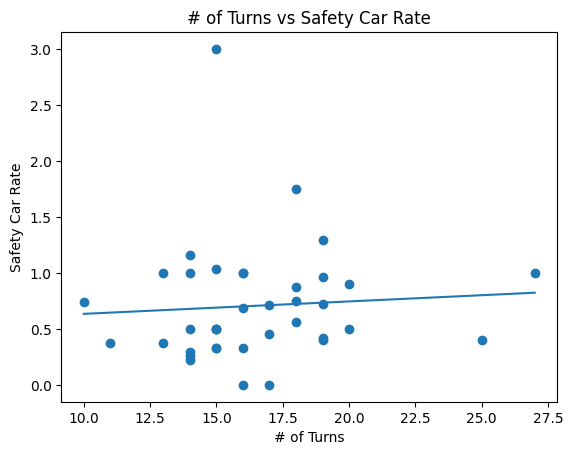

Correlation: 0.07
P-Value: 0.68


In [342]:
plt.title("# of Turns vs Safety Car Rate")
plt.xlabel("# of Turns")
plt.ylabel("Safety Car Rate")
plt.scatter(master_data['Turns'], master_data['Safety_Car_Rate'])
plt.plot(np.unique(master_data['Turns']), np.poly1d(np.polyfit(master_data['Turns'], master_data['Safety_Car_Rate'], 1))(np.unique(master_data['Turns'])))
plt.show()

corr = pearsonr(master_data['Turns'], master_data['Safety_Car_Rate'])
print(f"Correlation: {corr.correlation:.2f}")
print(f"P-Value: {corr.pvalue:.2f}")



- The regression line for **# of turns** vs the **rate of safety car** is almost flat, giving a very slight positive slope. This is showing that a higher number of corners does not mean a higher frequency of safety cars. 

### Number of Turns Vs Red Flag Rate

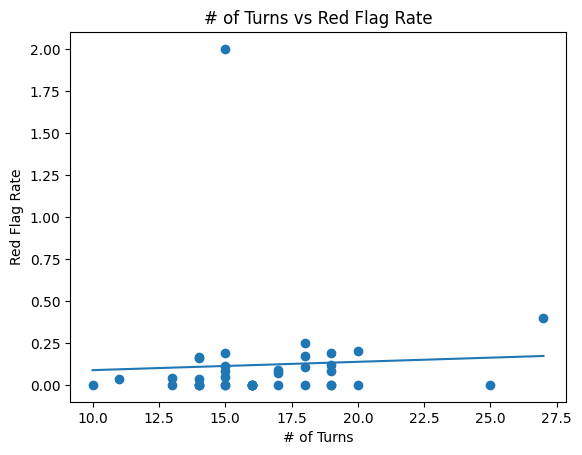

Correlation: 0.05
P-Value: 0.77


In [343]:
plt.title("# of Turns vs Red Flag Rate")
plt.xlabel("# of Turns")
plt.ylabel("Red Flag Rate")
plt.scatter(master_data['Turns'], master_data['Red_Flag_Rate'])
plt.plot(np.unique(master_data['Turns']), np.poly1d(np.polyfit(master_data['Turns'], master_data['Red_Flag_Rate'], 1))(np.unique(master_data['Turns'])))
plt.show()

corr = pearsonr(master_data['Turns'], master_data['Red_Flag_Rate'])
print(f"Correlation: {corr.correlation:.2f}")
print(f"P-Value: {corr.pvalue:.2f}")

- For red flags you can almost see a pattern on from turn 15 and turns > 25. Comparing to safety cars it looks as though those safety cars resulted in a red flag
- Regression line is basically flat

### Track Length Vs Safety Car Rate

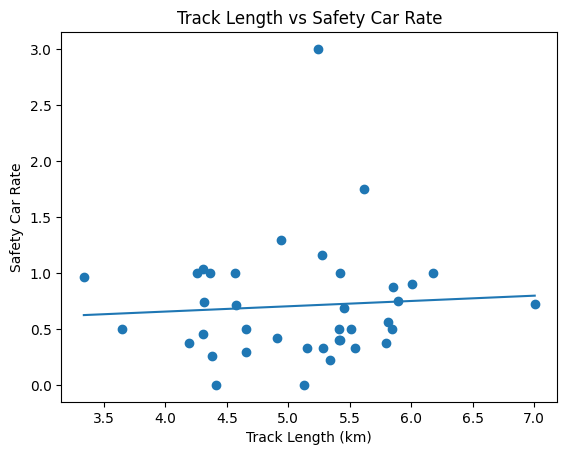

Correlation: 0.07
P-Value: 0.69


In [344]:
plt.title("Track Length vs Safety Car Rate")
plt.xlabel("Track Length (km)")
plt.ylabel("Safety Car Rate")
plt.scatter(master_data['Track_Length'], master_data['Safety_Car_Rate'])
plt.plot(np.unique(master_data['Track_Length']), np.poly1d(np.polyfit(master_data['Track_Length'], master_data['Safety_Car_Rate'], 1))(np.unique(master_data['Track_Length'])))
plt.show()

corr = pearsonr(master_data['Track_Length'], master_data['Safety_Car_Rate'])
print(f"Correlation: {corr.correlation:.2f}")
print(f"P-Value: {corr.pvalue:.2f}")

- Although the amount of safety cars is low, a lot more seems to happen on tracks between 4.5km and 6km in length. 
- Regression line slightly positive

### Track Length Vs Red Flag Rate

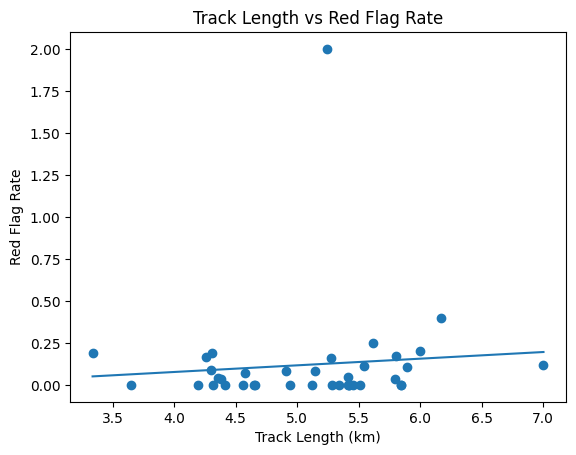

Correlation: 0.09
P-Value: 0.59


In [345]:
plt.title("Track Length vs Red Flag Rate")
plt.xlabel("Track Length (km)")
plt.ylabel("Red Flag Rate")
plt.scatter(master_data['Track_Length'], master_data['Red_Flag_Rate'])
plt.plot(np.unique(master_data['Track_Length']), np.poly1d(np.polyfit(master_data['Track_Length'], master_data['Red_Flag_Rate'], 1))(np.unique(master_data['Track_Length'])))
plt.show()

corr = pearsonr(master_data['Track_Length'], master_data['Red_Flag_Rate'])
print(f"Correlation: {corr.correlation:.2f}")
print(f"P-Value: {corr.pvalue:.2f}")

- Seeing a similar pattern as before where data is clumped together around the same track length as the safety car. Safety car and red flag rate and definitely going to be highly correlated
- Regression line slightly positive

### Track Direction vs Safety Car Rate

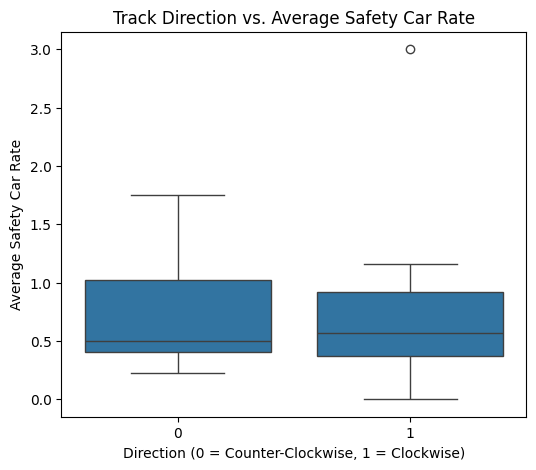

Correlation: -0.06
P-Value: 0.70


In [346]:
plt.figure(figsize=(6, 5))
plt.title("Track Direction vs. Average Safety Car Rate")
sns.boxplot(data=master_data, x='Direction', y='Safety_Car_Rate')
plt.xlabel("Direction (0 = Counter-Clockwise, 1 = Clockwise)")
plt.ylabel("Average Safety Car Rate")
plt.show()

corr = pearsonr(master_data['Direction'], master_data['Safety_Car_Rate'])
print(f"Correlation: {corr.correlation:.2f}")
print(f"P-Value: {corr.pvalue:.2f}")

- A track that drives clockwise is the true outlier with an average of 3 safety cars
- It looks like there is an equal number of tracks for each direction
- Dont think the direction will be significant in the end result

### Track Direction vs Red Flag Rate

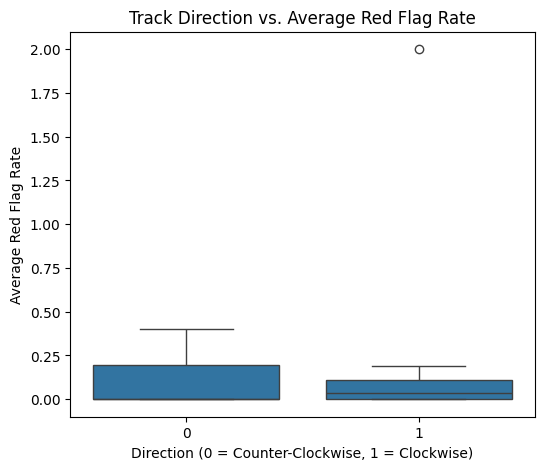

Correlation: 0.04
P-Value: 0.83


In [347]:
plt.figure(figsize=(6, 5))
plt.title("Track Direction vs. Average Red Flag Rate")
sns.boxplot(data=master_data, x='Direction', y='Red_Flag_Rate')
plt.xlabel("Direction (0 = Counter-Clockwise, 1 = Clockwise)")
plt.ylabel("Average Red Flag Rate")
plt.show()


corr = pearsonr(master_data['Direction'], master_data['Red_Flag_Rate'])
print(f"Correlation: {corr.correlation:.2f}")
print(f"P-Value: {corr.pvalue:.2f}")

- This box plot makes me more confident that I should be analyzing the safety car and red flag rating separately.
- Almost all tracks no matter what direction have a red flag rating close to zero.

### Altitude vs Safety Car Rate

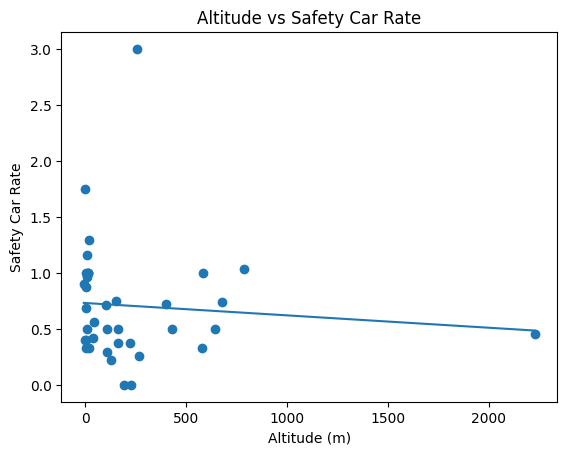

Correlation: -0.08
P-Value: 0.62


In [348]:
plt.title("Altitude vs Safety Car Rate")
plt.xlabel("Altitude (m)")
plt.ylabel("Safety Car Rate")
plt.scatter(master_data['Altitude'], master_data['Safety_Car_Rate'])
plt.plot(np.unique(master_data['Altitude']), np.poly1d(np.polyfit(master_data['Altitude'], master_data['Safety_Car_Rate'], 1))(np.unique(master_data['Altitude'])))
plt.show()

corr = pearsonr(master_data['Altitude'], master_data['Safety_Car_Rate'])
print(f"Correlation: {corr.correlation:.2f}")
print(f"P-Value: {corr.pvalue:.2f}")


- Most of the F1 tracks sit below 500 meters above sea level
- Slight negative regression line, heavily influenced by single track at 2000m+ above sea level. 
- Altitude does not effect the drivers ability to handle low downforce on track as much as I expected

### Altitude Vs Red Flag Rate

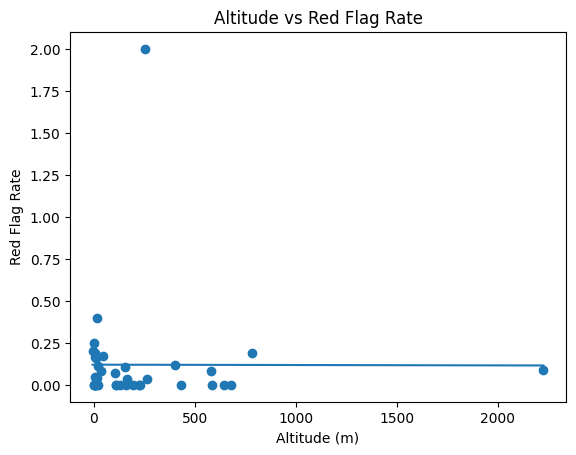

Correlation: -0.00
P-Value: 0.99


In [349]:
plt.title("Altitude vs Red Flag Rate")
plt.xlabel("Altitude (m)")
plt.ylabel("Red Flag Rate")
plt.scatter(master_data['Altitude'], master_data['Red_Flag_Rate'])
plt.plot(np.unique(master_data['Altitude']), np.poly1d(np.polyfit(master_data['Altitude'], master_data['Red_Flag_Rate'], 1))(np.unique(master_data['Altitude'])))
plt.show()

corr = pearsonr(master_data['Altitude'], master_data['Red_Flag_Rate'])
print(f"Correlation: {corr.correlation:.2f}")
print(f"P-Value: {corr.pvalue:.2f}")

- Regression line is completely flat, altitude has no significance in a race being stopped
- Outlier sits around 250m above sea level, this outlier can be seen in all graphs. 

### Circuit Type vs Safety Car/Red Flag Rate

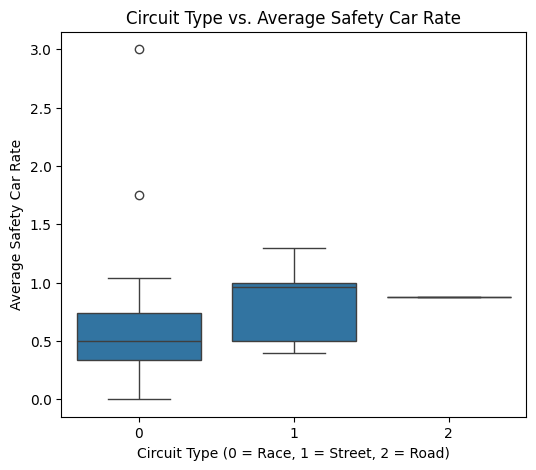

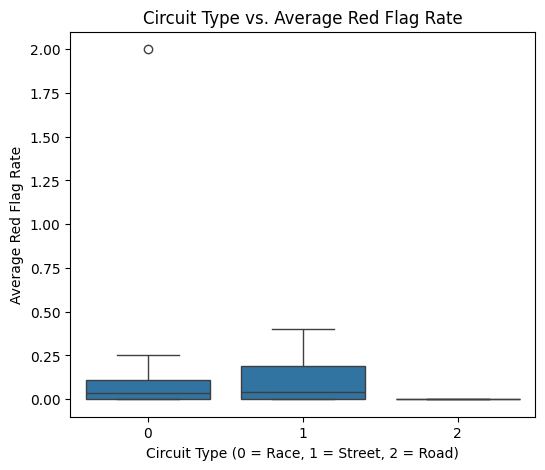

Correlation: 0.16
P-Value: 0.34


In [350]:
plt.figure(figsize=(6, 5))
plt.title("Circuit Type vs. Average Safety Car Rate")
sns.boxplot(data=master_data, x='Circuit_Type', y='Safety_Car_Rate')
plt.xlabel("Circuit Type (0 = Race, 1 = Street, 2 = Road)")
plt.ylabel("Average Safety Car Rate")
plt.show()

plt.figure(figsize=(6, 5))
plt.title("Circuit Type vs. Average Red Flag Rate")
sns.boxplot(data=master_data, x='Circuit_Type', y='Red_Flag_Rate')
plt.xlabel("Circuit Type (0 = Race, 1 = Street, 2 = Road)")
plt.ylabel("Average Red Flag Rate")
plt.show()

corr = pearsonr(master_data['Circuit_Type'], master_data['Safety_Car_Rate'])
print(f"Correlation: {corr.correlation:.2f}")
print(f"P-Value: {corr.pvalue:.2f}")

- Street circuits show a higher median safety car rate compared to other circuits.
- Road circuits show up as flat lines indicating a very small sample size in the data

### Normalization

In [351]:
from sklearn.preprocessing import MinMaxScaler


columns_to_scale = ['Track_Length', 'Turns', 'Altitude', 'Safety_Car_Rate', 'Red_Flag_Rate']
scaler = MinMaxScaler()
scaled_master_data = master_data.copy()
scaler.fit(master_data[columns_to_scale])
scaled_master_data[columns_to_scale] = scaler.transform(scaled_master_data[columns_to_scale])
scaled_master_data.drop(columns=['Circuit','circuitId', 'name', 'country'], inplace=True, errors='ignore')
print(scaled_master_data.head())

   Track_Length     Turns  Direction  Altitude  Circuit_Type  Safety_Car_Rate  \
2      0.428688  0.529412          0  0.019696             0         0.138889   
4      0.520316  0.294118          1  0.117278             0         1.000000   
6      0.727025  0.588235          0  0.000000             1         0.300000   
7      0.565858  0.294118          1  0.006267             0         0.166667   
8      0.085356  0.235294          0  0.290510             1         0.166667   

   Red_Flag_Rate  
2       0.041667  
4       1.000000  
6       0.100000  
7       0.022727  
8       0.000000  


### Weighting and Aggregation

I was completely unsure of what this step entailed so I used Gemini to try and understand what are the steps I need to take to attempt it properly. Here is the chat - https://gemini.google.com/share/6cb44d98bf5d

What I learned is that from the variables I have in my scaled master data, I need to create sub indexes and give the variables in them weights that are used to calculate the overall difficulty of a track. There are 3 ways I could decide on the weights - 
- **Equal Weighting** - Everything gets the same weight to equal to 1.0 in total. Don't like this approach, seems lazy.
- **Expert Weighting** - Domain expert assigns weights based on their own judgement. As an F1 can I think I could do this one.
- **Statistical Weighting** - Doing Principal Component Analysis to assign weights based on variance in the data.

For this I want to try doing PCA to see what information it can provide me. If not I will follow expert weighting.

### Principal Component Analysis

In [352]:

pca = PCA()
pca.fit(scaled_master_data)
per_var = np.round(pca.explained_variance_ratio_ * 100, decimals=1)
per_var


array([47.6, 28.3,  8.8,  7.5,  4.2,  2.8,  0.8])

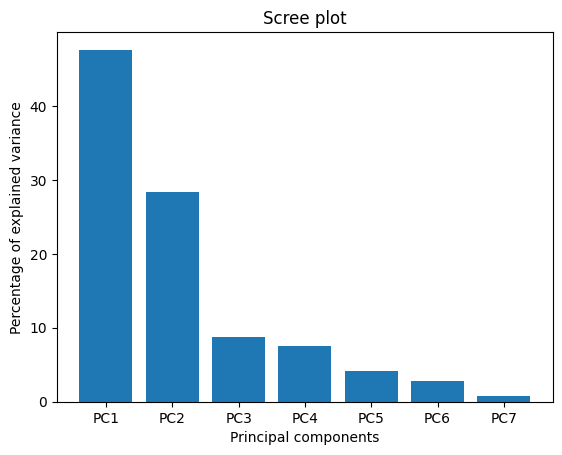

In [353]:
labels = ['PC'+str(i) for i in range(1, len(per_var)+1)]
plt.bar(x = range(1, len(per_var)+1), height = per_var, tick_label=labels)
plt.ylabel("Percentage of explained variance")
plt.xlabel("Principal components")
plt.title("Scree plot")
plt.show()

In [354]:
loading_scores_all = pd.Series(pca.components_[0], index = scaled_master_data.columns)
print(*loading_scores_all)

sorted_loading_scores_all = loading_scores_all.abs().sort_values(ascending=False)
top_variables = sorted_loading_scores_all[0:10].index.values
print(top_variables.tolist())

0.03789031466927063 0.18569559757115334 -0.5040820217754816 -0.08779270136297257 0.8361301121352308 0.054938834830844614 -0.011974389973886819
['Circuit_Type', 'Direction', 'Turns', 'Altitude', 'Safety_Car_Rate', 'Track_Length', 'Red_Flag_Rate']


PCA is showing that Circuit_Type and Direction are capturing most of the data and it creates a situation where it will favour a certain type of circuit in a certain direction. Out of curiosity I want to see how the PCA performs when these two columns are dropped

   Track_Length     Turns  Altitude  Safety_Car_Rate  Red_Flag_Rate
2      0.428688  0.529412  0.019696         0.138889       0.041667
4      0.520316  0.294118  0.117278         1.000000       1.000000
6      0.727025  0.588235  0.000000         0.300000       0.100000
7      0.565858  0.294118  0.006267         0.166667       0.022727
8      0.085356  0.235294  0.290510         0.166667       0.000000
Loading Scores (Weights):
Track_Length       0.644114
Turns              0.526493
Altitude           0.361464
Safety_Car_Rate    0.317111
Red_Flag_Rate      0.276960
dtype: float64


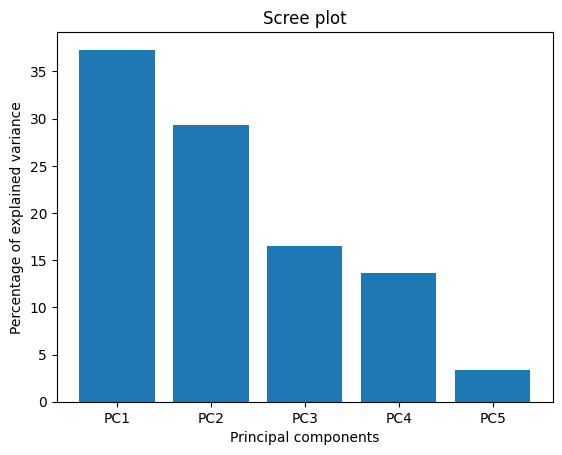

In [355]:

scaled_master_data_v2 = master_data.copy()
scaler.fit(master_data[columns_to_scale])
scaled_master_data_v2[columns_to_scale] = scaler.transform(scaled_master_data_v2[columns_to_scale])
scaled_master_data_v2.drop(columns=['Circuit','circuitId', 'name', 'country', 'Circuit_Type', 'Direction'], inplace=True, errors='ignore')
print(scaled_master_data_v2.head())

pca = PCA()
pca.fit(scaled_master_data_v2)
per_var = np.round(pca.explained_variance_ratio_ * 100, decimals=1)
per_var

loading_scores_no_categorical = pd.Series(pca.components_[0], index=scaled_master_data_v2.columns)
print("Loading Scores (Weights):")
print(loading_scores_no_categorical.abs().sort_values(ascending=False))

labels = ['PC'+str(i) for i in range(1, len(per_var)+1)]
plt.bar(x = range(1, len(per_var)+1), height = per_var, tick_label=labels)
plt.ylabel("Percentage of explained variance")
plt.xlabel("Principal components")
plt.title("Scree plot")
plt.show()

### Creating Index without Categorical Variables (Circuit Type / Direction)

I was unsure how to create sub indexes and how to use them to create a final composite index. To figure this out I consulted Gemini. Here is the chat - https://gemini.google.com/share/c102d57598a4 </br>
For this index I am going to use 3 sub indexes to calculate the overall score - 


In [356]:

# Normalize weights so that sum to 1 ( 100% )
abs_scores = loading_scores_no_categorical.abs()
normalized_weights = abs_scores / abs_scores.sum()
print("Normalized Loading Scores (Weights):")
print(normalized_weights.sort_values(ascending=False))

Normalized Loading Scores (Weights):
Track_Length       0.302950
Turns              0.247628
Altitude           0.170009
Safety_Car_Rate    0.149149
Red_Flag_Rate      0.130264
dtype: float64


In [357]:
scaled_master_data_no_categorical = master_data.copy()
scaler.fit(master_data[columns_to_scale])
scaled_master_data_no_categorical[columns_to_scale] = scaler.transform(scaled_master_data_no_categorical[columns_to_scale])
scaled_master_data_no_categorical.drop(columns=['Circuit','circuitId', 'name', 'country', 'Circuit_Type', 'Direction'], inplace=True, errors='ignore')
print(scaled_master_data_no_categorical.head())

real_weights = abs_scores / abs_scores.sum()
print("--- STATISTICAL WEIGHTS ---")
print(real_weights.sort_values(ascending=False))
print("-------------------------------------\n")

master_data['Complexity_Score'] = (
    (scaled_master_data_no_categorical['Turns'] * real_weights['Turns']) + 
    (scaled_master_data_no_categorical['Safety_Car_Rate'] * real_weights['Safety_Car_Rate']) + 
    (scaled_master_data_no_categorical['Track_Length'] * real_weights['Track_Length']) + 
    (scaled_master_data_no_categorical['Red_Flag_Rate'] * real_weights['Red_Flag_Rate']) + 
    (scaled_master_data_no_categorical['Altitude'] * real_weights['Altitude'])
)

index_no_categorical = master_data[['Circuit', 'Complexity_Score']].sort_values(by='Complexity_Score', ascending=False)
index_no_categorical['Position'] = range(1, len(index_no_categorical) + 1)
index_no_categorical

   Track_Length     Turns  Altitude  Safety_Car_Rate  Red_Flag_Rate
2      0.428688  0.529412  0.019696         0.138889       0.041667
4      0.520316  0.294118  0.117278         1.000000       1.000000
6      0.727025  0.588235  0.000000         0.300000       0.100000
7      0.565858  0.294118  0.006267         0.166667       0.022727
8      0.085356  0.235294  0.290510         0.166667       0.000000
--- STATISTICAL WEIGHTS ---
Track_Length       0.302950
Turns              0.247628
Altitude           0.170009
Safety_Car_Rate    0.149149
Red_Flag_Rate      0.130264
dtype: float64
-------------------------------------



,Circuit,Complexity_Score,Position
46,Jeddah Corniche Circuit,0.559451,1
4,Autodromo Internazionale del Mugello,0.529813,2
27,Circuit de Spa-Francorchamps,0.508708,3
6,Baku City Circuit,0.423687,4
76,Valencia Street Circuit,0.411224,5
48,Korea International Circuit,0.408547,6
73,Silverstone Circuit,0.383972,7
17,Autódromo Hermanos Rodríguez,0.380382,8
70,Sochi Autodrom,0.368164,9
71,Suzuka Circuit,0.363976,10


### Creating Index with All Variables

In [358]:
abs_scores = loading_scores_all.abs()
normalized_weights = abs_scores / abs_scores.sum()
print("Normalized Loading Scores (Weights):")
print(normalized_weights.sort_values(ascending=False))

Normalized Loading Scores (Weights):
Circuit_Type       0.486545
Direction          0.293326
Turns              0.108057
Altitude           0.051087
Safety_Car_Rate    0.031969
Track_Length       0.022048
Red_Flag_Rate      0.006968
dtype: float64


In [359]:
scaled_master_data_all = master_data.copy()
scaler.fit(master_data[columns_to_scale])
scaled_master_data_all[columns_to_scale] = scaler.transform(scaled_master_data_all[columns_to_scale])
scaled_master_data_all.drop(columns=['Circuit','circuitId', 'name', 'country'], inplace=True, errors='ignore')


real_weights = abs_scores / abs_scores.sum()
print("--- STATISTICAL WEIGHTS ---")
print(real_weights.sort_values(ascending=False))
print("-------------------------------------\n")

scaled_master_data_all.head()
master_data['Complexity_Score'] = (
    (scaled_master_data_all['Turns'] * real_weights['Turns']) + 
    (scaled_master_data_all['Safety_Car_Rate'] * real_weights['Safety_Car_Rate']) + 
    (scaled_master_data_all['Track_Length'] * real_weights['Track_Length']) + 
    (scaled_master_data_all['Red_Flag_Rate'] * real_weights['Red_Flag_Rate']) + 
    (scaled_master_data_all['Altitude'] * real_weights['Altitude']) +
    (scaled_master_data_all['Direction'] * real_weights['Direction']) +
    (scaled_master_data_all['Circuit_Type'] * real_weights['Circuit_Type'])
)

index_all = master_data[['Circuit', 'Complexity_Score']].sort_values(by='Complexity_Score', ascending=False)
index_all['Position'] = range(1, len(index_all) + 1)
index_all


--- STATISTICAL WEIGHTS ---
Circuit_Type       0.486545
Direction          0.293326
Turns              0.108057
Altitude           0.051087
Safety_Car_Rate    0.031969
Track_Length       0.022048
Red_Flag_Rate      0.006968
dtype: float64
-------------------------------------



,Circuit,Complexity_Score,Position
70,Sochi Autodrom,1.341895,1
76,Valencia Street Circuit,0.892248,2
25,Circuit de Monaco,0.848314,3
54,Melbourne Grand Prix Circuit,0.830275,4
26,Circuit Gilles Villeneuve,0.816356,5
46,Jeddah Corniche Circuit,0.624213,6
6,Baku City Circuit,0.576425,7
53,Marina Bay Street Circuit,0.567752,8
55,Miami International Autodrome,0.560651,9
8,Caesars Palace,0.534022,10


### Comparing Indexes

In [360]:
index_all

,Circuit,Complexity_Score,Position
70,Sochi Autodrom,1.341895,1
76,Valencia Street Circuit,0.892248,2
25,Circuit de Monaco,0.848314,3
54,Melbourne Grand Prix Circuit,0.830275,4
26,Circuit Gilles Villeneuve,0.816356,5
46,Jeddah Corniche Circuit,0.624213,6
6,Baku City Circuit,0.576425,7
53,Marina Bay Street Circuit,0.567752,8
55,Miami International Autodrome,0.560651,9
8,Caesars Palace,0.534022,10


In [361]:
index_no_categorical

,Circuit,Complexity_Score,Position
46,Jeddah Corniche Circuit,0.559451,1
4,Autodromo Internazionale del Mugello,0.529813,2
27,Circuit de Spa-Francorchamps,0.508708,3
6,Baku City Circuit,0.423687,4
76,Valencia Street Circuit,0.411224,5
48,Korea International Circuit,0.408547,6
73,Silverstone Circuit,0.383972,7
17,Autódromo Hermanos Rodríguez,0.380382,8
70,Sochi Autodrom,0.368164,9
71,Suzuka Circuit,0.363976,10


The first index that includes all variables is heavily dominated by street circuits. Sochi, Valencia, Monaco, Melbourne, Montreal, Jeddah, Baku, Marina Bay, and Miami are in the top 10 and all of them are street circuits. Because circuit type and direction and binary categorical variables it creates a massive leap in variance that the algorithm latches onto. This results in the categorical variables being given a massive bonus score to any track in that category </br>

Removing the categorical variables in the second index, it looks more aligned with what I would expect. These tracks are considered more mechanically and aerodynamically complex. Jeddah and Baku are still at the top which is fair as they have extreme speed, wall proximity and technical challenges. Whats different now is some of the heavy hitters like Mugello, Spa, Silverstone and Suzuka have appeared. These are classic tracks known for high speed corners, aerodynamic load and complex degradation profiles. I am a slight bit surprised that Monaco has dropped all the way down to 32nd place. This shows just how much the circuit type and direction as influencing the result. While Monaco is a difficult track is is also one of the most boring races to watch as nothing happens. Cars are much bigger now and drivers only have 1 or 2 opportunities to overtake. As an F1 fan this makes sense but this is a complexity index and Monaco is more difficult than complex.

### Creating Indexes from Sub-Indexes

After reviewing what the indexes look like using all weights in 1 equation, now I want to create sub-indexes that will be used to calculate an overall score. This will be reviewed against the two previous indexes.

In [362]:
# Normalize weights so that sum to 1 ( 100% )
abs_scores = loading_scores.abs()
normalized_weights = abs_scores / abs_scores.sum()
print("Normalized Loading Scores (Weights):")
print(normalized_weights.sort_values(ascending=False))

NameError: name 'loading_scores' is not defined

In [ ]:

abs_scores = loading_scores.abs()
real_weights = abs_scores / abs_scores.sum()
print("--- STATISTICAL WEIGHTS ---")
print(real_weights.sort_values(ascending=False))
print("-------------------------------------\n")

master_data['Complexity_Score'] = (
    (scaled_master_data_v2['Turns'] * real_weights['Turns']) + 
    (scaled_master_data_v2['Safety_Car_Rate'] * real_weights['Safety_Car_Rate']) + 
    (scaled_master_data_v2['Track_Length'] * real_weights['Track_Length']) + 
    (scaled_master_data_v2['Red_Flag_Rate'] * real_weights['Red_Flag_Rate']) + 
    (scaled_master_data_v2['Altitude'] * real_weights['Altitude'])
)

top_tracks = master_data[['Circuit', 'Complexity_Score']].sort_values(by='Complexity_Score', ascending=False)
top_tracks['Position'] = range(1, len(top_tracks) + 1)
top_tracks

--- STATISTICAL WEIGHTS ---
Circuit_Type       0.486545
Direction          0.293326
Turns              0.108057
Altitude           0.051087
Safety_Car_Rate    0.031969
Track_Length       0.022048
Red_Flag_Rate      0.006968
dtype: float64
-------------------------------------



,Circuit,Complexity_Score,Position
46,Jeddah Corniche Circuit,0.137667,1
76,Valencia Street Circuit,0.112376,2
17,Autódromo Hermanos Rodríguez,0.106555,3
27,Circuit de Spa-Francorchamps,0.096676,4
6,Baku City Circuit,0.089880,5
4,Autodromo Internazionale del Mugello,0.088182,6
34,Circuit of the Americas,0.085816,7
48,Korea International Circuit,0.084227,8
53,Marina Bay Street Circuit,0.081207,9
73,Silverstone Circuit,0.078231,10


In [ ]:
# Track Layout Sub-Index
track_layout_cols = ['Turns', 'Track_Length']

# Environment Sub-Index
environment_cols = ['Altitude']

# Safety Sub-Index
safety_cols = ['Safety_Car_Rate', 'Red_Flag_Rate']

In [ ]:
layout_data = scaled_master_data[track_layout_cols]

pca_layout = PCA().fit(layout_data)
layout_weights = pd.Series(pca_layout.components_[0], index=track_layout_cols).abs()
layout_weights = layout_weights / layout_weights.sum() 

print("--- WEIGHTS ---")
print(layout_weights.sort_values(ascending=False))
print("-------------------------------------\n")

master_data['Layout_Score'] = (
    (layout_data['Turns'] * layout_weights['Turns']) + 
    (layout_data['Track_Length'] * layout_weights['Track_Length'])
)

master_data[['Circuit', 'Layout_Score']].sort_values(by='Layout_Score', ascending=False).head()

--- WEIGHTS ---
Track_Length    0.535331
Turns           0.464669
dtype: float64
-------------------------------------



,Circuit,Layout_Score
46,Jeddah Corniche Circuit,0.878832
27,Circuit de Spa-Francorchamps,0.781332
76,Valencia Street Circuit,0.713945
6,Baku City Circuit,0.662534
73,Silverstone Circuit,0.591516


In [ ]:
environment_cols = ['Altitude']
env_data = scaled_master_data[environment_cols]

pca_env = PCA().fit(env_data)
env_weights = pd.Series(pca_env.components_[0], index=environment_cols).abs()
env_weights = env_weights / env_weights.sum() 

print("--- WEIGHTS ---")
print(env_weights.sort_values(ascending=False))
print("-------------------------------------\n")

master_data['Environment_Score'] = (
    (env_data['Altitude'] * env_weights['Altitude']) 
)

master_data[['Circuit', 'Environment_Score']].sort_values(by='Environment_Score', ascending=False).head()

--- WEIGHTS ---
Altitude    1.0
dtype: float64
-------------------------------------



,Circuit,Environment_Score
17,Autódromo Hermanos Rodríguez,1.000000
11,Autódromo José Carlos Pace,0.354521
67,Red Bull Ring,0.306625
8,Caesars Palace,0.290510
42,Fuji Speedway,0.264100


In [ ]:
safety_cols = ['Safety_Car_Rate', 'Red_Flag_Rate']
safety_data = scaled_master_data[safety_cols]

pca_safety = PCA().fit(safety_data)
safety_weights = pd.Series(pca_safety.components_[0], index=safety_cols).abs()
safety_weights = safety_weights / safety_weights.sum() 

print("--- WEIGHTS ---")
print(safety_weights.sort_values(ascending=False))
print("-------------------------------------\n")

master_data['Safety_Score'] = (
    (safety_data['Safety_Car_Rate'] * safety_weights['Safety_Car_Rate']) + 
    (safety_data['Red_Flag_Rate'] * safety_weights['Red_Flag_Rate'])
)

master_data[['Circuit', 'Safety_Score']].sort_values(by='Safety_Score', ascending=False).head()

--- WEIGHTS ---
Safety_Car_Rate    0.524758
Red_Flag_Rate      0.475242
dtype: float64
-------------------------------------



,Circuit,Safety_Score
4,Autodromo Internazionale del Mugello,1.000000
48,Korea International Circuit,0.365514
46,Jeddah Corniche Circuit,0.269968
54,Melbourne Grand Prix Circuit,0.240926
11,Autódromo José Carlos Pace,0.227343


In [ ]:
master_data['Final_Complexity_Score'] = (
    (master_data['Layout_Score'] * 0.333) +
    (master_data['Environment_Score'] * 0.333) +
    (master_data['Safety_Score'] * 0.333)
)

display_cols = ['Circuit', 'Layout_Score', 'Environment_Score', 'Safety_Score', 'Final_Complexity_Score']
top_tracks = master_data[display_cols].sort_values(by='Final_Complexity_Score', ascending=False).reset_index(drop=True)
top_tracks.index = top_tracks.index + 1 

print("--- THE FINAL F1 COMPLEXITY INDEX (YOUR GROUPING) ---")
top_tracks

--- THE FINAL F1 COMPLEXITY INDEX (YOUR GROUPING) ---


,Circuit,Layout_Score,Environment_Score,Safety_Score,Final_Complexity_Score
1,Autodromo Internazionale del Mugello,0.415209,0.117278,1.000000,0.510318
2,Autódromo Hermanos Rodríguez,0.332503,1.000000,0.101111,0.477393
3,Jeddah Corniche Circuit,0.878832,0.009848,0.269968,0.385830
4,Circuit de Spa-Francorchamps,0.781332,0.182632,0.154456,0.372434
5,Korea International Circuit,0.551224,0.003133,0.365514,0.306317
6,Baku City Circuit,0.662534,0.000000,0.204952,0.288873
7,Autódromo José Carlos Pace,0.278566,0.354521,0.227343,0.286523
8,Silverstone Circuit,0.591516,0.071620,0.156649,0.272989
9,Valencia Street Circuit,0.713945,0.004924,0.069968,0.262683
10,Circuit Paul Ricard,0.502362,0.196509,0.087460,0.261848
